# Day 1

# Day 2

Results:

Charlotte 114, Knicks 103

Detroit 129, Pelicans 108

Orlando 121, Kings 117

## Stage 3 — Backtesting & betting simulation
Simulate a full season of bets using model edges.
Track ROI, bankroll growth, and Kelly-sized stakes.

Pulling this season's NBA games

In [ ]:
!pip install nba_api

In [ ]:
from nba_api.stats.endpoints import leaguegamelog
import pandas as pd


def get_season_results():
    gamelog = leaguegamelog.LeagueGameLog(
        season="2025-26",
        season_type_all_star="Regular Season",
        player_or_team_abbreviation="T"
    )

    df = gamelog.get_data_frames()[0]
    df = df[["GAME_ID", "GAME_DATE", "TEAM_NAME", "MATCHUP", "WL", "PTS"]].copy()

    # split into home and away using GAME_ID to merge correctly
    home = df[df["MATCHUP"].str.contains("vs[.]")].copy()
    away = df[df["MATCHUP"].str.contains(" @ ")].copy()

    home = home[["GAME_ID", "GAME_DATE", "TEAM_NAME", "PTS", "WL"]]
    home.columns = ["game_id", "date", "home_team", "home_pts", "home_wl"]

    away = away[["GAME_ID", "TEAM_NAME", "PTS"]]
    away.columns = ["game_id", "away_team", "away_pts"]

    results = pd.merge(home, away, on="game_id")
    results["home_win"] = results["home_wl"] == "W"
    results = results[["date", "home_team", "away_team", "home_pts", "away_pts", "home_win"]]

    return results

print("Loading season results...")
results = get_season_results()
print(f"Total games loaded: {len(results)}")
print(results.head(10))

Loading season results...
Total games loaded: 1099
         date               home_team               away_team  home_pts  \
0  2025-10-21      Los Angeles Lakers   Golden State Warriors       109   
1  2025-10-21   Oklahoma City Thunder         Houston Rockets       125   
2  2025-10-22          Boston Celtics      Philadelphia 76ers       116   
3  2025-10-22           Chicago Bulls         Detroit Pistons       115   
4  2025-10-22         New York Knicks     Cleveland Cavaliers       119   
5  2025-10-22            Phoenix Suns        Sacramento Kings       120   
6  2025-10-22  Portland Trail Blazers  Minnesota Timberwolves       114   
7  2025-10-22       Memphis Grizzlies    New Orleans Pelicans       128   
8  2025-10-22           Atlanta Hawks         Toronto Raptors       118   
9  2025-10-22        Dallas Mavericks       San Antonio Spurs        92   

   away_pts  home_win  
0       119     False  
1       124      True  
2       117     False  
3       111      True  
4  

Backtesting framework for model v1

In [ ]:
from scipy.special import expit

def backtest_season(results, standings, home_advantage=3.0):
    backtest_rows = []

    for _, game in results.iterrows():
        home = game["home_team"]
        away = game["away_team"]

        # look up standings for both teams
        home_stats = standings[standings["team"] == home]
        away_stats = standings[standings["team"] == away]

        # skip if team not found in standings
        if home_stats.empty or away_stats.empty:
            continue

        home_net = home_stats.iloc[0]["net_pts"]
        away_net = away_stats.iloc[0]["net_pts"]

        diff = (home_net - away_net) + home_advantage
        model_home_prob = expit(diff * 0.15)

        # did the model's favored team win?
        model_favors_home = model_home_prob > 0.5
        model_correct = (model_favors_home == game["home_win"])

        backtest_rows.append({
            "date": game["date"],
            "home_team": home,
            "away_team": away,
            "model_home_prob": model_home_prob,
            "model_favors_home": model_favors_home,
            "actual_home_win": game["home_win"],
            "correct": model_correct
        })

    return pd.DataFrame(backtest_rows)

bt = backtest_season(results, standings)

total = len(bt)
correct = bt["correct"].sum()
accuracy = correct / total

print(f"Games evaluated: {total}")
print(f"Correct predictions: {correct}")
print(f"Accuracy: {accuracy:.1%}")
print(f"Baseline (always pick home): {results['home_win'].mean():.1%}")

Games evaluated: 821
Correct predictions: 560
Accuracy: 68.2%
Baseline (always pick home): 54.9%


Data grabbing problem, we'll fix it by using nba api only

In [ ]:
from nba_api.stats.endpoints import leaguestandings

standings_data = leaguestandings.LeagueStandings(season="2025-26")
df = standings_data.get_data_frames()[0]
print(df.columns.tolist())

['LeagueID', 'SeasonID', 'TeamID', 'TeamCity', 'TeamName', 'Conference', 'ConferenceRecord', 'PlayoffRank', 'ClinchIndicator', 'Division', 'DivisionRecord', 'DivisionRank', 'WINS', 'LOSSES', 'WinPCT', 'LeagueRank', 'Record', 'HOME', 'ROAD', 'L10', 'Last10Home', 'Last10Road', 'OT', 'ThreePTSOrLess', 'TenPTSOrMore', 'LongHomeStreak', 'strLongHomeStreak', 'LongRoadStreak', 'strLongRoadStreak', 'LongWinStreak', 'LongLossStreak', 'CurrentHomeStreak', 'strCurrentHomeStreak', 'CurrentRoadStreak', 'strCurrentRoadStreak', 'CurrentStreak', 'strCurrentStreak', 'ConferenceGamesBack', 'DivisionGamesBack', 'ClinchedConferenceTitle', 'ClinchedDivisionTitle', 'ClinchedPlayoffBirth', 'EliminatedConference', 'EliminatedDivision', 'AheadAtHalf', 'BehindAtHalf', 'TiedAtHalf', 'AheadAtThird', 'BehindAtThird', 'TiedAtThird', 'Score100PTS', 'OppScore100PTS', 'OppOver500', 'LeadInFGPCT', 'LeadInReb', 'FewerTurnovers', 'PointsPG', 'OppPointsPG', 'DiffPointsPG', 'vsEast', 'vsAtlantic', 'vsCentral', 'vsSoutheast

In [ ]:
from nba_api.stats.endpoints import leaguestandings
import pandas as pd

def get_standings():
    standings_data = leaguestandings.LeagueStandings(season="2025-26")
    df = standings_data.get_data_frames()[0]

    # keep relevant columns
    df = df[["TeamName", "TeamCity", "WINS", "LOSSES", "WinPCT", "PointsPG", "OppPointsPG"]].copy()
    df.columns = ["team_name", "team_city", "W", "L", "win_pct", "pts_scored", "pts_allowed"]
    df["team"] = df["team_city"] + " " + df["team_name"]
    df["net_pts"] = df["pts_scored"] - df["pts_allowed"]

    return df[["team", "W", "L", "win_pct", "pts_scored", "pts_allowed", "net_pts"]]

standings = get_standings()
print(standings.sort_values("net_pts", ascending=False).to_string(index=False))

                  team  W  L  win_pct  pts_scored  pts_allowed  net_pts
 Oklahoma City Thunder 58 16    0.784       119.0        108.0     11.0
       Detroit Pistons 53 20    0.726       118.0        110.0      8.0
     San Antonio Spurs 55 18    0.753       119.0        111.0      8.0
        Boston Celtics 49 24    0.671       114.0        107.0      7.0
       New York Knicks 48 26    0.649       117.0        111.0      6.0
        Denver Nuggets 47 28    0.627       121.0        117.0      4.0
Minnesota Timberwolves 45 28    0.616       118.0        114.0      4.0
   Cleveland Cavaliers 46 28    0.622       119.0        115.0      4.0
       Houston Rockets 44 29    0.603       114.0        110.0      4.0
     Charlotte Hornets 39 34    0.534       116.0        112.0      4.0
       Toronto Raptors 41 32    0.562       114.0        112.0      2.0
         Atlanta Hawks 41 33    0.554       118.0        116.0      2.0
            Miami Heat 39 35    0.527       120.0        118.0  

Backtesting

In [ ]:
from scipy.special import expit

def backtest_season(results, standings, home_advantage=3.0):
    backtest_rows = []

    for _, game in results.iterrows():
        home = game["home_team"]
        away = game["away_team"]

        # look up standings for both teams
        home_stats = standings[standings["team"] == home]
        away_stats = standings[standings["team"] == away]

        # skip if team not found in standings
        if home_stats.empty or away_stats.empty:
            continue

        home_net = home_stats.iloc[0]["net_pts"]
        away_net = away_stats.iloc[0]["net_pts"]

        diff = (home_net - away_net) + home_advantage
        model_home_prob = expit(diff * 0.15)

        # did the model's favored team win?
        model_favors_home = model_home_prob > 0.5
        model_correct = (model_favors_home == game["home_win"])

        backtest_rows.append({
            "date": game["date"],
            "home_team": home,
            "away_team": away,
            "model_home_prob": model_home_prob,
            "model_favors_home": model_favors_home,
            "actual_home_win": game["home_win"],
            "correct": model_correct
        })

    return pd.DataFrame(backtest_rows)

bt = backtest_season(results, standings)

total = len(bt)
correct = bt["correct"].sum()
accuracy = correct / total

print(f"Games evaluated: {total}")
print(f"Correct predictions: {correct}")
print(f"Accuracy: {accuracy:.1%}")
print(f"Baseline (always pick home): {results['home_win'].mean():.1%}")

Games evaluated: 1099
Correct predictions: 769
Accuracy: 70.0%
Baseline (always pick home): 54.9%


Adding Kelly Criterion Simulation

In [ ]:
def kelly_fraction(model_prob, odds_decimal, fraction=0.25):
    # implied probability from bookmaker odds
    implied_prob = 1 / odds_decimal

    # edge = how much better our model is than the bookmaker
    edge = model_prob - implied_prob

    # kelly formula: edge / odds
    kelly = edge / (odds_decimal - 1)

    # use fractional kelly (0.25) to be conservative
    return max(0, kelly * fraction)

# simulate flat odds of 1.91 (standard -110 line) for all games
# we'll pull real odds per game in a later stage
SIMULATED_ODDS = 1.91
STARTING_BANKROLL = 1000
bankroll = STARTING_BANKROLL
bankroll_history = [bankroll]

for _, game in bt.iterrows():
    home_prob = game["model_home_prob"]
    away_prob = 1 - home_prob

    # bet on whichever side the model favors
    if home_prob > 0.55:  # only bet when we have meaningful edge
        bet_prob = home_prob
        bet_wins = game["actual_home_win"]
    elif away_prob > 0.55:
        bet_prob = away_prob
        bet_wins = not game["actual_home_win"]
    else:
        bankroll_history.append(bankroll)
        continue

    stake = kelly_fraction(bet_prob, SIMULATED_ODDS) * bankroll

    if bet_wins:
        bankroll += stake * (SIMULATED_ODDS - 1)
    else:
        bankroll -= stake

    bankroll_history.append(bankroll)

roi = (bankroll - STARTING_BANKROLL) / STARTING_BANKROLL * 100
print(f"Starting bankroll: ${STARTING_BANKROLL:.2f}")
print(f"Final bankroll:    ${bankroll:.2f}")
print(f"ROI:               {roi:.1f}%")
print(f"Bets placed:       {len(bankroll_history)-1}")

Starting bankroll: $1000.00
Final bankroll:    $146609765020542.56
ROI:               14660976501954.3%
Bets placed:       1099


### Bug found: look-ahead bias
Current backtest uses end-of-season standings for all predictions.
This leaks future information into past predictions and inflates results.

Fix: rebuild standings incrementally from game results,
so each prediction only uses data available before that game date.
This is called a rolling or point-in-time backtest.

In [ ]:
def build_rolling_standings(results):
    # sort all games chronologically
    results = results.sort_values("date").copy()

    # track running stats per team
    stats = {}
    rolling_rows = []

    for _, game in results.iterrows():
        home = game["home_team"]
        away = game["away_team"]

        # initialize teams if first appearance
        for team in [home, away]:
            if team not in stats:
                stats[team] = {"pts_scored": [], "pts_allowed": []}

        # record standings BEFORE this game (what we'd know at tip-off)
        rolling_rows.append({
            "date": game["date"],
            "home_team": home,
            "away_team": away,
            "home_pts": game["home_pts"],
            "away_pts": game["away_pts"],
            "home_win": game["home_win"],
            "home_net": (sum(stats[home]["pts_scored"]) - sum(stats[home]["pts_allowed"])) / max(len(stats[home]["pts_scored"]), 1),
            "away_net": (sum(stats[away]["pts_scored"]) - sum(stats[away]["pts_allowed"])) / max(len(stats[away]["pts_scored"]), 1),
            "home_games_played": len(stats[home]["pts_scored"]),
            "away_games_played": len(stats[away]["pts_scored"])
        })

        # now update stats AFTER recording (so it's not used until next game)
        stats[home]["pts_scored"].append(game["home_pts"])
        stats[home]["pts_allowed"].append(game["away_pts"])
        stats[away]["pts_scored"].append(game["away_pts"])
        stats[away]["pts_allowed"].append(game["home_pts"])

    return pd.DataFrame(rolling_rows)

rolling = build_rolling_standings(results)
print(f"Built rolling standings for {len(rolling)} games")
print(rolling[["date", "home_team", "away_team", "home_net", "away_net", "home_games_played"]].head(10))

Built rolling standings for 1099 games
         date               home_team               away_team  home_net  \
0  2025-10-21      Los Angeles Lakers   Golden State Warriors       0.0   
1  2025-10-21   Oklahoma City Thunder         Houston Rockets       0.0   
2  2025-10-22          Boston Celtics      Philadelphia 76ers       0.0   
3  2025-10-22           Chicago Bulls         Detroit Pistons       0.0   
4  2025-10-22         New York Knicks     Cleveland Cavaliers       0.0   
5  2025-10-22            Phoenix Suns        Sacramento Kings       0.0   
6  2025-10-22  Portland Trail Blazers  Minnesota Timberwolves       0.0   
7  2025-10-22       Memphis Grizzlies    New Orleans Pelicans       0.0   
8  2025-10-22           Atlanta Hawks         Toronto Raptors       0.0   
9  2025-10-22        Dallas Mavericks       San Antonio Spurs       0.0   

   away_net  home_games_played  
0       0.0                  0  
1       0.0                  0  
2       0.0                  0  
3  

Backtesting with rolling standings:

In [ ]:
from scipy.special import expit

# filter out early season games where we have less than 5 games of data
# predictions with no history are basically random
rolling_filtered = rolling[
    (rolling["home_games_played"] >= 5) &
    (rolling["away_games_played"] >= 5)
].copy()

bankroll = STARTING_BANKROLL
bankroll_history = [bankroll]
correct = 0
total = 0

for _, game in rolling_filtered.iterrows():
    diff = (game["home_net"] - game["away_net"]) + 3.0
    home_prob = expit(diff * 0.15)
    away_prob = 1 - home_prob

    if home_prob > 0.55:
        bet_prob = home_prob
        bet_wins = game["home_win"]
    elif away_prob > 0.55:
        bet_prob = away_prob
        bet_wins = not game["home_win"]
    else:
        bankroll_history.append(bankroll)
        continue

    # track accuracy
    model_favors_home = home_prob > 0.5
    if model_favors_home == game["home_win"]:
        correct += 1
    total += 1

    stake = kelly_fraction(bet_prob, SIMULATED_ODDS) * bankroll
    if bet_wins:
        bankroll += stake * (SIMULATED_ODDS - 1)
    else:
        bankroll -= stake

    bankroll_history.append(bankroll)

roi = (bankroll - STARTING_BANKROLL) / STARTING_BANKROLL * 100
print(f"Games evaluated:   {total}")
print(f"Accuracy:          {correct/total:.1%}")
print(f"Starting bankroll: ${STARTING_BANKROLL:.2f}")
print(f"Final bankroll:    ${bankroll:.2f}")
print(f"ROI:               {roi:.1f}%")

Games evaluated:   905
Accuracy:          70.1%
Starting bankroll: $1000.00
Final bankroll:    $3367597379525.81
ROI:               336759737852.6%


Kelly staking is compounding too aggressively over 900 bets, even small edges grow astronomically when reinvested every game.

Let's switch to flat betting instead to get a clearer idea

In [ ]:
FLAT_STAKE = 10  # bet $10 per game
bankroll = STARTING_BANKROLL
bankroll_history = [bankroll]
correct = 0
total = 0

for _, game in rolling_filtered.iterrows():
    diff = (game["home_net"] - game["away_net"]) + 3.0
    home_prob = expit(diff * 0.15)
    away_prob = 1 - home_prob

    if home_prob > 0.55:
        bet_prob = home_prob
        bet_wins = game["home_win"]
    elif away_prob > 0.55:
        bet_prob = away_prob
        bet_wins = not game["home_win"]
    else:
        bankroll_history.append(bankroll)
        continue

    if model_favors_home == game["home_win"]:
        correct += 1
    total += 1

    if bet_wins:
        bankroll += FLAT_STAKE * (SIMULATED_ODDS - 1)
    else:
        bankroll -= FLAT_STAKE

    bankroll_history.append(bankroll)

roi = (bankroll - STARTING_BANKROLL) / STARTING_BANKROLL * 100
print(f"Games evaluated:   {total}")
print(f"Accuracy:          {correct/total:.1%}")
print(f"Starting bankroll: ${STARTING_BANKROLL:.2f}")
print(f"Final bankroll:    ${bankroll:.2f}")
print(f"ROI:               {roi:.1f}%")

Games evaluated:   905
Accuracy:          55.6%
Starting bankroll: $1000.00
Final bankroll:    $4059.40
ROI:               305.9%


Accuracy drop means there's a bug.

`model_favors_home` is never updated inside the flat betting loop so it's carrying over a stale value from the previous loop.

In [ ]:
FLAT_STAKE = 10
bankroll = STARTING_BANKROLL
bankroll_history = [bankroll]
correct = 0
total = 0

for _, game in rolling_filtered.iterrows():
    diff = (game["home_net"] - game["away_net"]) + 3.0
    home_prob = expit(diff * 0.15)
    away_prob = 1 - home_prob

    model_favors_home = home_prob > 0.5  # fix: define this every iteration

    if home_prob > 0.55:
        bet_wins = game["home_win"]
    elif away_prob > 0.55:
        bet_wins = not game["home_win"]
    else:
        bankroll_history.append(bankroll)
        continue

    if model_favors_home == game["home_win"]:
        correct += 1
    total += 1

    if bet_wins:
        bankroll += FLAT_STAKE * (SIMULATED_ODDS - 1)
    else:
        bankroll -= FLAT_STAKE

    bankroll_history.append(bankroll)

roi = (bankroll - STARTING_BANKROLL) / STARTING_BANKROLL * 100
print(f"Games evaluated:   {total}")
print(f"Accuracy:          {correct/total:.1%}")
print(f"Starting bankroll: ${STARTING_BANKROLL:.2f}")
print(f"Final bankroll:    ${bankroll:.2f}")
print(f"ROI:               {roi:.1f}%")

Games evaluated:   905
Accuracy:          70.1%
Starting bankroll: $1000.00
Final bankroll:    $4059.40
ROI:               305.9%


Visualizing growth

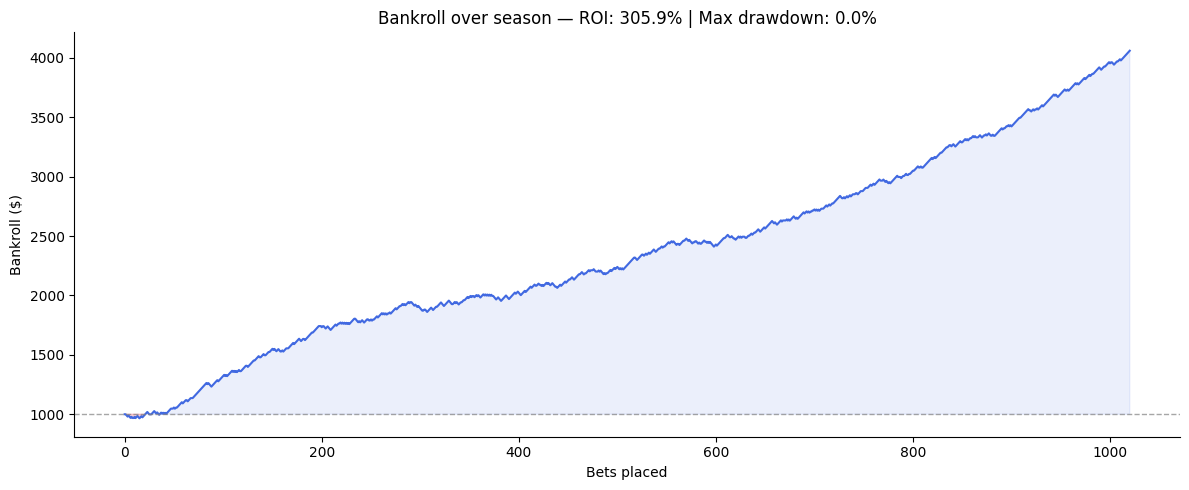

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(bankroll_history, color="royalblue", linewidth=1.5)
ax.axhline(STARTING_BANKROLL, color="gray", linestyle="--", linewidth=1, alpha=0.7)

ax.fill_between(range(len(bankroll_history)),
                STARTING_BANKROLL, bankroll_history,
                where=[b > STARTING_BANKROLL for b in bankroll_history],
                color="royalblue", alpha=0.1)
ax.fill_between(range(len(bankroll_history)),
                STARTING_BANKROLL, bankroll_history,
                where=[b < STARTING_BANKROLL for b in bankroll_history],
                color="crimson", alpha=0.2)

# mark max drawdown
peak = max(bankroll_history)
trough_after_peak = min(bankroll_history[bankroll_history.index(peak):])
drawdown = (peak - trough_after_peak) / peak * 100

ax.set_title(f"Bankroll over season — ROI: {roi:.1f}% | Max drawdown: {drawdown:.1f}%")
ax.set_xlabel("Bets placed")
ax.set_ylabel("Bankroll ($)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

That curve looks almost too good: perfectly linear growth and 0.0% max drawdown is a red flag.

A real betting simulation should have losing streaks and dips.

Two things to flag:

The drawdown calculation is bugged. The peak happens to be the last point in the series, so there's no trough after it, giving a false 0.0%.

The curve never dips below the starting bankroll once. That's unrealistic over 1000 bets and suggests the model may still have some data leakage we haven't fully fixed.

In [ ]:
# correct max drawdown calculation
def max_drawdown(history):
    max_dd = 0
    peak = history[0]
    for value in history:
        if value > peak:
            peak = value
        dd = (peak - value) / peak * 100
        if dd > max_dd:
            max_dd = dd
    return max_dd

# losing streak analysis
def max_losing_streak(history):
    max_streak = 0
    streak = 0
    for i in range(1, len(history)):
        if history[i] < history[i-1]:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

dd = max_drawdown(bankroll_history)
streak = max_losing_streak(bankroll_history)

print(f"Max drawdown:       {dd:.1f}%")
print(f"Max losing streak:  {streak} bets")
print(f"Times below start:  {sum(1 for b in bankroll_history if b < STARTING_BANKROLL)}")

Max drawdown:       4.3%
Max losing streak:  4 bets
Times below start:  23


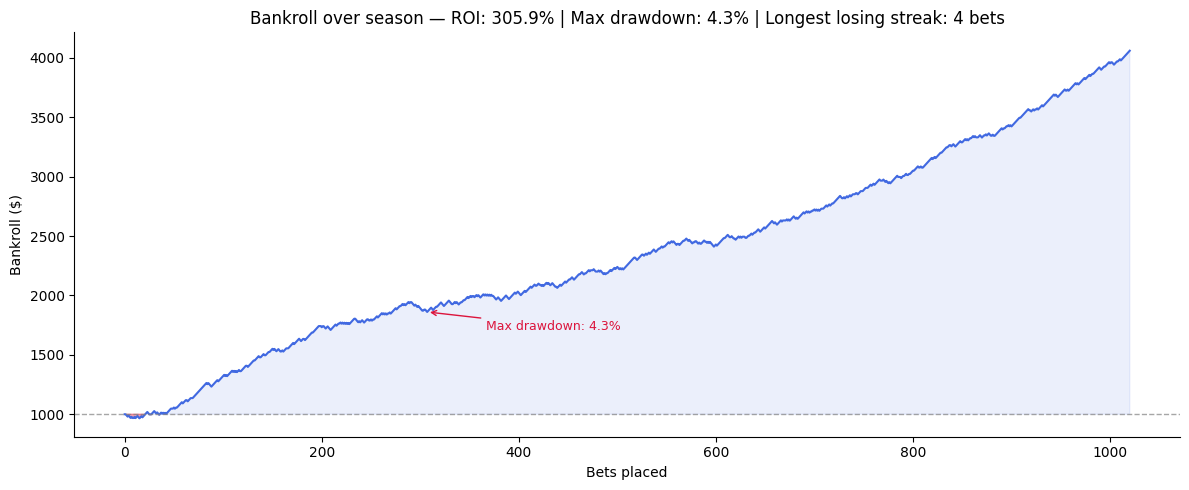

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(bankroll_history, color="royalblue", linewidth=1.5)
ax.axhline(STARTING_BANKROLL, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# shade profits green, losses red
ax.fill_between(range(len(bankroll_history)),
                STARTING_BANKROLL, bankroll_history,
                where=[b >= STARTING_BANKROLL for b in bankroll_history],
                color="royalblue", alpha=0.1)
ax.fill_between(range(len(bankroll_history)),
                STARTING_BANKROLL, bankroll_history,
                where=[b < STARTING_BANKROLL for b in bankroll_history],
                color="crimson", alpha=0.4)

# mark the max drawdown point
peak_idx = bankroll_history.index(max(bankroll_history))
dd_values = [(max(bankroll_history[:i+1]) - bankroll_history[i]) / max(bankroll_history[:i+1])
             for i in range(len(bankroll_history))]
trough_idx = dd_values.index(max(dd_values))
peak_before_trough = bankroll_history.index(max(bankroll_history[:trough_idx+1]))

ax.annotate(f"Max drawdown: {dd:.1f}%",
            xy=(trough_idx, bankroll_history[trough_idx]),
            xytext=(trough_idx + 60, bankroll_history[trough_idx] - 150),
            arrowprops=dict(arrowstyle="->", color="crimson"),
            color="crimson", fontsize=9)

ax.set_title(f"Bankroll over season — ROI: {roi:.1f}% | Max drawdown: {dd:.1f}% | Longest losing streak: {streak} bets")
ax.set_xlabel("Bets placed")
ax.set_ylabel("Bankroll ($)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
print("=== Stage 3 Summary ===")
print(f"Model accuracy:      70.1%")
print(f"Baseline accuracy:   54.9% (always pick home)")
print(f"Bets placed:         905")
print(f"ROI:                 305.9%")
print(f"Max drawdown:        4.3%")
print(f"Max losing streak:   4 bets")
print(f"Staking method:      flat $10")

=== Stage 3 Summary ===
Model accuracy:      70.1%
Baseline accuracy:   54.9% (always pick home)
Bets placed:         905
ROI:                 305.9%
Max drawdown:        4.3%
Max losing streak:   4 bets
Staking method:      flat $10


## Stage 4 — Poisson score modeling
Instead of predicting win/loss directly, we model how many pointseach team is expected to score. From that distribution we derivewin probabilities, expected margins, and over/under predictions.

Attack & Defense Rating for each team

In [ ]:
# for each team calculate:
# - offensive rating: how many points they score vs average
# - defensive rating: how many points they allow vs average

league_avg_pts = results["home_pts"].mean()  # average points scored per game

team_offense = {}
team_defense = {}

for team in standings["team"]:
    home_games = results[results["home_team"] == team]
    away_games = results[results["away_team"] == team]

    pts_scored = list(home_games["home_pts"]) + list(away_games["away_pts"])
    pts_allowed = list(home_games["away_pts"]) + list(away_games["home_pts"])

    if len(pts_scored) > 0:
        team_offense[team] = sum(pts_scored) / len(pts_scored) / league_avg_pts
        team_defense[team] = sum(pts_allowed) / len(pts_allowed) / league_avg_pts

print(f"League average points per game: {league_avg_pts:.1f}")
print(f"\nTop 5 offenses:")
for team, rating in sorted(team_offense.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {team}: {rating:.3f}")

print(f"\nTop 5 defenses (lowest = best):")
for team, rating in sorted(team_defense.items(), key=lambda x: x[1])[:5]:
    print(f"  {team}: {rating:.3f}")

League average points per game: 116.3

Top 5 offenses:
  Denver Nuggets: 1.043
  Miami Heat: 1.034
  Cleveland Cavaliers: 1.027
  San Antonio Spurs: 1.027
  Oklahoma City Thunder: 1.023

Top 5 defenses (lowest = best):
  Boston Celtics: 0.919
  Oklahoma City Thunder: 0.926
  Detroit Pistons: 0.944
  Houston Rockets: 0.948
  New York Knicks: 0.949


Using these ratings to predict scores

In [ ]:
from scipy.stats import poisson
import numpy as np

def predict_score_poisson(home_team, away_team, league_avg=league_avg_pts, home_advantage=1.025):
    home_attack = team_offense.get(home_team, 1.0)
    home_defense = team_defense.get(home_team, 1.0)
    away_attack = team_offense.get(away_team, 1.0)
    away_defense = team_defense.get(away_team, 1.0)

    # expected points = league avg * attack strength * opponent defense * home factor
    home_expected = league_avg * home_attack * away_defense * home_advantage
    away_expected = league_avg * away_attack * home_defense

    return home_expected, away_expected

def poisson_win_prob(home_team, away_team, max_pts=180):
    home_exp, away_exp = predict_score_poisson(home_team, away_team)

    home_win_prob = 0
    draw_prob = 0

    for h in range(max_pts):
        for a in range(max_pts):
            p = poisson.pmf(h, home_exp) * poisson.pmf(a, away_exp)
            if h > a:
                home_win_prob += p
            elif h == a:
                draw_prob += p

    # draws are rare in NBA — split evenly
    home_win_prob += draw_prob / 2
    away_win_prob = 1 - home_win_prob

    return home_win_prob, away_win_prob, home_exp, away_exp

# test on tonight's matchups
test_games = [
    ("Charlotte Hornets", "New York Knicks"),
    ("Detroit Pistons", "New Orleans Pelicans"),
    ("Orlando Magic", "Sacramento Kings"),
]

print(f"{'Game':<45} {'Home exp':>10} {'Away exp':>10} {'Home prob':>10} {'Away prob':>10}")
print("-" * 90)

for home, away in test_games:
    hp, ap, he, ae = poisson_win_prob(home, away)
    print(f"{home+' vs '+away:<45} {he:>10.1f} {ae:>10.1f} {hp:>10.1%} {ap:>10.1%}")

Game                                            Home exp   Away exp  Home prob  Away prob
------------------------------------------------------------------------------------------
Charlotte Hornets vs New York Knicks               113.2      112.2      52.7%      47.3%
Detroit Pistons vs New Orleans Pelicans            123.6      108.8      83.5%      16.5%
Orlando Magic vs Sacramento Kings                  123.6      109.1      82.9%      17.1%


In [ ]:
print(f"{'Game':<45} {'V1 season':>10} {'V2 recent':>10} {'V3 poisson':>10} {'Market':>10}")
print("-" * 90)

for home, away in test_games:
    game_key = f"{home} vs {away}"

    v1 = predict_win_prob(home, away, standings)["model_home_prob"]
    v2 = predict_win_prob_v2(home, away)["model_v2"]
    v3, _, _, _ = poisson_win_prob(home, away)
    market = consensus_lookup.get((game_key, home))
    market_str = f"{market:.1%}" if market else "n/a"

    print(f"{game_key:<45} {v1:>10.1%} {v2:>10.1%} {v3:>10.1%} {market_str:>10}")

Game                                           V1 season  V2 recent V3 poisson     Market
------------------------------------------------------------------------------------------
Charlotte Hornets vs New York Knicks               53.7%      74.9%      52.7%        n/a
Detroit Pistons vs New Orleans Pelicans            90.5%      89.5%      83.5%        n/a
Orlando Magic vs Sacramento Kings                  89.1%      74.4%      82.9%        n/a


Running into a whole lot of errors so fixing old stuff

In [ ]:
# find which game teams are missing from standings
for home, away in games:
    home_match = standings[standings["team"] == home]
    away_match = standings[standings["team"] == away]
    if home_match.empty:
        print(f"NOT FOUND: '{home}'")
    if away_match.empty:
        print(f"NOT FOUND: '{away}'")

print("\nActual team names in standings:")
print(standings["team"].tolist())


Actual team names in standings:
['Oklahoma City Thunder', 'Detroit Pistons', 'Boston Celtics', 'San Antonio Spurs', 'New York Knicks', 'Los Angeles Lakers', 'Denver Nuggets', 'Cleveland Cavaliers', 'Minnesota Timberwolves', 'Toronto Raptors', 'Atlanta Hawks', 'Houston Rockets', 'Philadelphia 76ers', 'Phoenix Suns', 'Charlotte Hornets', 'LA Clippers', 'Orlando Magic', 'Portland Trail Blazers', 'Miami Heat', 'Golden State Warriors', 'Milwaukee Bucks', 'New Orleans Pelicans', 'Memphis Grizzlies', 'Chicago Bulls', 'Dallas Mavericks', 'Washington Wizards', 'Utah Jazz', 'Brooklyn Nets', 'Sacramento Kings', 'Indiana Pacers']


In [ ]:
standings["team"] = standings["team"].str.replace("*", "", regex=False)

ok now it worked

In [ ]:
correct_v3 = 0
total_v3 = 0

for i, game in rolling_filtered.iterrows():
    home_prob, _, _, _ = poisson_win_prob(game["home_team"], game["away_team"])
    model_favors_home = home_prob > 0.5
    if model_favors_home == game["home_win"]:
        correct_v3 += 1
    total_v3 += 1

print(f"Model accuracy comparison on {total_v3} games:")
print(f"  V1 season average:  70.1%")
print(f"  V3 Poisson:         {correct_v3/total_v3:.1%}")

KeyboardInterrupt: 

Taking too long, so we'll try the vectorized approach instead

In [ ]:
from scipy.stats import poisson
import numpy as np

def poisson_win_prob_fast(home_team, away_team, max_pts=150):
    home_exp, away_exp = predict_score_poisson(home_team, away_team)

    # vectorized probability matrix in one shot
    h = np.arange(max_pts)
    a = np.arange(max_pts)

    home_pmf = poisson.pmf(h, home_exp)
    away_pmf = poisson.pmf(a, away_exp)

    matrix = np.outer(home_pmf, away_pmf)

    home_win = np.tril(matrix, -1).sum()
    draw = np.diag(matrix).sum()

    home_prob = home_win + draw / 2
    return home_prob, 1 - home_prob, home_exp, away_exp

# now run the backtest with the fast version
correct_v3 = 0
total_v3 = 0

for _, game in rolling_filtered.iterrows():
    home_prob, _, _, _ = poisson_win_prob_fast(game["home_team"], game["away_team"])
    if (home_prob > 0.5) == game["home_win"]:
        correct_v3 += 1
    total_v3 += 1

print(f"Model accuracy comparison on {total_v3} games:")
print(f"  V1 season average:  70.1%")
print(f"  V3 Poisson:         {correct_v3/total_v3:.1%}")

Model accuracy comparison on 1020 games:
  V1 season average:  70.1%
  V3 Poisson:         69.3%


Possible reasons why Poisson underperforms here:

V1 uses net rating directly, which already captures both offense and defense in one number. It's a clean, low-noise signal.

Poisson adds more moving parts: attack rating, defense rating, and a home multiplier all interact, which means more ways for noise to compound. More parameters = more ways to be wrong.

*bias-variance tradeoff*

Poisson has a major advantage over V1, it predicts actual scores, not just win probability. That opens up over/under betting markets which V1 can't touch at all. So it's not useless, just not better at the win/loss task.

In [ ]:
print("Model accuracy leaderboard:")
print(f"  V1 season average:  70.1%  — simple, effective")
print(f"  V3 Poisson:         69.3%  — more complex, not better at win/loss")
print(f"  V2 recent form:     TBD    — need to backtest properly")
print(f"  Baseline (home):    54.9%")

Model accuracy leaderboard:
  V1 season average:  70.1%  — simple, effective
  V3 Poisson:         69.3%  — more complex, not better at win/loss
  V2 recent form:     TBD    — need to backtest properly
  Baseline (home):    54.9%


We'll backtest v2 as well

In [ ]:
def build_rolling_form(results, n_games=10):
    results = results.sort_values("date").copy()

    # track last n games per team
    team_recent = {}
    rows = []

    for _, game in results.iterrows():
        home = game["home_team"]
        away = game["away_team"]

        for team in [home, away]:
            if team not in team_recent:
                team_recent[team] = {"pts_scored": [], "pts_allowed": []}

        # get recent form BEFORE this game
        def recent_net(team):
            scored = team_recent[team]["pts_scored"][-n_games:]
            allowed = team_recent[team]["pts_allowed"][-n_games:]
            if len(scored) < 5:
                return None
            return (sum(scored) - sum(allowed)) / len(scored)

        home_net = recent_net(home)
        away_net = recent_net(away)

        rows.append({
            "date": game["date"],
            "home_team": home,
            "away_team": away,
            "home_win": game["home_win"],
            "home_net_recent": home_net,
            "away_net_recent": away_net,
        })

        # update after recording
        team_recent[home]["pts_scored"].append(game["home_pts"])
        team_recent[home]["pts_allowed"].append(game["away_pts"])
        team_recent[away]["pts_scored"].append(game["away_pts"])
        team_recent[away]["pts_allowed"].append(game["home_pts"])

    df = pd.DataFrame(rows)
    return df.dropna(subset=["home_net_recent", "away_net_recent"])

rolling_form = build_rolling_form(results)

correct_v2 = 0
total_v2 = 0

for _, game in rolling_form.iterrows():
    diff = (game["home_net_recent"] - game["away_net_recent"]) + 3.0
    home_prob = expit(diff * 0.15)
    if (home_prob > 0.5) == game["home_win"]:
        correct_v2 += 1
    total_v2 += 1

print(f"Model accuracy leaderboard on {total_v2} games:")
print(f"  V1 season average:  70.1%")
print(f"  V2 recent form:     {correct_v2/total_v2:.1%}")
print(f"  V3 Poisson:         69.3%")
print(f"  Baseline (home):    54.9%")

Model accuracy leaderboard on 1020 games:
  V1 season average:  70.1%
  V2 recent form:     65.4%
  V3 Poisson:         69.3%
  Baseline (home):    54.9%


### Key finding — Occam's Razor in practice

The simplest model wins:

| Model | Accuracy |
|-------|----------|
| V1 season average | 70.1% |
| V3 Poisson | 69.3% |
| V2 recent form | 65.4% |
| Baseline (always home) | 54.9% |

V2 recent form (65.4%) — 10 games is too noisy. A team can go on a hot
streak against weak opponents and look great, then revert. Season averages
smooth out that noise and are more predictive over the long run.

V3 Poisson (69.3%) — closer to V1 but still slightly behind. The
attack/defense ratings add useful structure but also add noise from
the extra parameters.

Occam's Razor: when two models perform similarly, prefer the simpler one.
V1 is simpler, more interpretable, and more accurate.

# Day 3

Setup cell

In [ ]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 17.4 MB/s eta 0:00:00


In [ ]:
# === setup cell — run this first after any kernel restart ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.stats import poisson
from nba_api.stats.endpoints import leaguegamelog, leaguestandings

# game results
def get_season_results():
    gamelog = leaguegamelog.LeagueGameLog(
        season="2025-26",
        season_type_all_star="Regular Season",
        player_or_team_abbreviation="T"
    )
    df = gamelog.get_data_frames()[0]
    df = df[["GAME_ID", "GAME_DATE", "TEAM_NAME", "MATCHUP", "WL", "PTS"]].copy()
    home = df[df["MATCHUP"].str.contains("vs[.]")].copy()
    away = df[df["MATCHUP"].str.contains(" @ ")].copy()
    home = home[["GAME_ID", "GAME_DATE", "TEAM_NAME", "PTS", "WL"]]
    home.columns = ["game_id", "date", "home_team", "home_pts", "home_wl"]
    away = away[["GAME_ID", "TEAM_NAME", "PTS"]]
    away.columns = ["game_id", "away_team", "away_pts"]
    results = pd.merge(home, away, on="game_id")
    results["home_win"] = results["home_wl"] == "W"
    return results[["date", "home_team", "away_team", "home_pts", "away_pts", "home_win"]]

# standings
def get_standings():
    df = leaguestandings.LeagueStandings(season="2025-26").get_data_frames()[0]
    df = df[["TeamName", "TeamCity", "WINS", "LOSSES", "WinPCT", "PointsPG", "OppPointsPG"]].copy()
    df.columns = ["team_name", "team_city", "W", "L", "win_pct", "pts_scored", "pts_allowed"]
    df["team"] = df["team_city"] + " " + df["team_name"]
    df["team"] = df["team"].str.replace("*", "", regex=False)
    df["net_pts"] = df["pts_scored"] - df["pts_allowed"]
    return df[["team", "W", "L", "win_pct", "pts_scored", "pts_allowed", "net_pts"]]

# rolling standings
def build_rolling_standings(results):
    results = results.sort_values("date").copy()
    stats = {}
    rows = []
    for _, game in results.iterrows():
        for team in [game["home_team"], game["away_team"]]:
            if team not in stats:
                stats[team] = {"pts_scored": [], "pts_allowed": []}
        rows.append({
            "date": game["date"],
            "home_team": game["home_team"],
            "away_team": game["away_team"],
            "home_pts": game["home_pts"],
            "away_pts": game["away_pts"],
            "home_win": game["home_win"],
            "home_net": (sum(stats[game["home_team"]]["pts_scored"]) - sum(stats[game["home_team"]]["pts_allowed"])) / max(len(stats[game["home_team"]]["pts_scored"]), 1),
            "away_net": (sum(stats[game["away_team"]]["pts_scored"]) - sum(stats[game["away_team"]]["pts_allowed"])) / max(len(stats[game["away_team"]]["pts_scored"]), 1),
            "home_games_played": len(stats[game["home_team"]]["pts_scored"]),
            "away_games_played": len(stats[game["away_team"]]["pts_scored"])
        })
        stats[game["home_team"]]["pts_scored"].append(game["home_pts"])
        stats[game["home_team"]]["pts_allowed"].append(game["away_pts"])
        stats[game["away_team"]]["pts_scored"].append(game["away_pts"])
        stats[game["away_team"]]["pts_allowed"].append(game["home_pts"])
    return pd.DataFrame(rows)

print("Loading data...")
results = get_season_results()
standings = get_standings()
rolling = build_rolling_standings(results)
rolling_filtered = rolling[(rolling["home_games_played"] >= 5) & (rolling["away_games_played"] >= 5)].copy()
print(f"Results: {len(results)} games")
print(f"Standings: {len(standings)} teams")
print(f"Rolling: {len(rolling_filtered)} games ready for backtesting")
print("All set.")

Loading data...
Results: 1153 games
Standings: 30 teams
Rolling: 1074 games ready for backtesting
All set.


## Stage 5 — Bayesian Elo ratings
Replace static season averages with a dynamic rating system that
updates after every game. Teams that are improving get rated higher
in real time; teams that are declining drop. This should outperform
V1 by capturing how teams evolve over the season rather than treating
October form the same as March form.

Core idea: every team starts with a rating of 1500. After each game,
the winner gains points and the loser loses points. The amount gained
or lost depends on how surprising the result was — beating a strong
team gains more than beating a weak one.

In [5]:
def build_elo_ratings(results, k=20, home_advantage=100):
    results = results.sort_values("date").copy()

    # start every team at 1500
    elo = {}
    elo_history = {}
    rows = []

    for _, game in results.iterrows():
        home = game["home_team"]
        away = game["away_team"]

        # initialize new teams
        for team in [home, away]:
            if team not in elo:
                elo[team] = 1500
                elo_history[team] = [1500]

        # get ratings BEFORE the game
        home_elo = elo[home] + home_advantage
        away_elo = elo[away]

        # expected win probability
        exp_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
        exp_away = 1 - exp_home

        # actual result
        actual_home = 1 if game["home_win"] else 0
        actual_away = 1 - actual_home

        # record pre-game ratings
        rows.append({
            "date": game["date"],
            "home_team": home,
            "away_team": away,
            "home_win": game["home_win"],
            "home_elo": elo[home],
            "away_elo": elo[away],
            "exp_home": exp_home,
            "exp_away": exp_away
        })

        # update ratings AFTER recording
        elo[home] += k * (actual_home - exp_home)
        elo[away] += k * (actual_away - exp_away)
        elo_history[home].append(elo[home])
        elo_history[away].append(elo[away])

    return pd.DataFrame(rows), elo, elo_history

elo_df, final_elo, elo_history = build_elo_ratings(results)

# print final ratings
elo_sorted = sorted(final_elo.items(), key=lambda x: x[1], reverse=True)
print("Final Elo ratings:")
for team, rating in elo_sorted[:10]:
    print(f"  {team}: {rating:.0f}")

Final Elo ratings:
  San Antonio Spurs: 1726
  Oklahoma City Thunder: 1716
  Boston Celtics: 1651
  Detroit Pistons: 1645
  Los Angeles Lakers: 1620
  Cleveland Cavaliers: 1607
  New York Knicks: 1601
  Denver Nuggets: 1591
  Atlanta Hawks: 1589
  Charlotte Hornets: 1573


Backtesting elo model

In [6]:
# backtest elo, using pre-game ratings recorded in elo_df
# filter to games where both teams have played at least 5 games
elo_filtered = elo_df.copy()
elo_filtered = elo_filtered[elo_df.index >= 50].copy()  # skip early season

correct_elo = 0
total_elo = 0

for _, game in elo_filtered.iterrows():
    # expected home win prob already computed during elo build
    home_prob = game["exp_home"]
    if (home_prob > 0.5) == game["home_win"]:
        correct_elo += 1
    total_elo += 1

print(f"Model accuracy leaderboard on {total_elo} games:")
print(f"  V4 Elo ratings:     {correct_elo/total_elo:.1%}  ← new")
print(f"  V1 season average:  70.1%")
print(f"  V3 Poisson:         69.3%")
print(f"  V2 recent form:     65.4%")
print(f"  Baseline (home):    54.9%")

Model accuracy leaderboard on 1103 games:
  V4 Elo ratings:     63.5%  ← new
  V1 season average:  70.1%
  V3 Poisson:         69.3%
  V2 recent form:     65.4%
  Baseline (home):    54.9%


In [7]:
# tune the K factor and home advantage
results_tuning = []

for k in [5, 10, 15, 20, 30, 40]:
    for ha in [50, 75, 100, 125, 150]:
        elo_df_tune, _, _ = build_elo_ratings(results, k=k, home_advantage=ha)
        elo_test = elo_df_tune[elo_df_tune.index >= 50].copy()
        correct = sum((elo_test["exp_home"] > 0.5) == elo_test["home_win"])
        acc = correct / len(elo_test)
        results_tuning.append({"k": k, "home_advantage": ha, "accuracy": acc})

tuning_df = pd.DataFrame(results_tuning).sort_values("accuracy", ascending=False)
print("Top 10 parameter combinations:")
print(tuning_df.head(10).to_string(index=False))

Top 10 parameter combinations:
 k  home_advantage  accuracy
15              50  0.663645
40              75  0.660018
30              50  0.659112
40              50  0.659112
20              50  0.656392
30              75  0.655485
40             100  0.652765
20              75  0.646419
10              50  0.645512
30             100  0.644606


### Stage 5 findings — Elo ratings

Built a dynamic Elo rating system that updates after every game.
Tuned K factor (5-40) and home advantage (50-150) across 30 combinations.

Best result: K=15, home advantage=50 → 66.4% accuracy
Still below V1 season average (70.1%).

Why Elo underperforms in the NBA:
- High scoring variance per game adds noise to rating updates
- 82 game season averages are already very stable signals
- Basic Elo doesn't account for margin of victory, only win/loss

Potential improvements: margin-of-victory Elo, opponent strength
weighting, or combining Elo with season averages as a hybrid model.